# Simple Credit Analysis

## Análise de Crédito usando Machine Learning

Este notebook explora dados públicos do LendingClub.com para criar um modelo de classificação que ajuda a prever se um mutuário pagará o empréstimo integralmente ou não.

### 📋 Resumo Executivo

- **Dataset**: Empréstimos de 2007-2010 do LendingClub (9.578 registros)
- **Objetivo**: Classificar se o mutuário pagou o empréstimo na íntegra (`not.fully.paid`)
- **Abordagem**: Análise Exploratória de Dados (EDA) + Modelos de Machine Learning (Decision Tree e Random Forest)
- **Desafio Principal**: Desbalanceamento de classes (~84% pagadores vs ~16% não pagadores)

### 📊 Resultados Principais

| Modelo | Acurácia | Precision (classe 1) | Recall (classe 1) | F1-score (classe 1) |
|--------|----------|---------------------|-------------------|-------------------|
| Decision Tree | 72% | 19% | 24% | 21% |
| Random Forest | 85% | 52% | 3% | 5% |

> **Nota**: A acurácia elevada do Random Forest é enganosa devido ao desbalanceamento das classes. O modelo tem dificuldade em identificar mutuários que não pagarão o empréstimo.

### 🚀 Como Executar

```bash
# Instale as dependências
pip install -r requirements.txt

# Inicie o Jupyter
jupyter notebook
```

---

# 1. Introdução

# Descrição do contexto e objetivo
Para este projeto, estaremos explorando dados disponíveis publicamente de LendingCLub.com. LendingClub conecta pessoas que precisam de dinheiro (mutuários) com pessoas que têm dinheiro (investidores). Felizmente, como investirdor, você gostaria de investir em pessoas que pagam seus empréstimos. Vamos tentar criar um modelo que ajude a prever se o mutuário pagará o empréstimo ou não.

O clube de empréstimo teve um ano muito interessante em 2016, então vamos verificar alguns de seus dados e ter em mente o contexto. Esses dados são de antes mesmo de serem publicos. 

Utilizaremos os dados de emprestimo de 2007-2010 e tentaremos classificar se o mutuário pagou o empréstimo na integra.

### 📁 Informações do Dataset

- **Fonte**: LendingClub.com (dados públicos de 2007-2010)
- **Total de Registros**: 9.578 empréstimos
- **Total de Variáveis**: 14 (13 features + 1 target)
- **Variável Target**: `not.fully.paid` (0 = pagou integralmente, 1 = não pagou integralmente)
- **Distribuição do Target**: ~84% classe 0, ~16% classe 1 (desbalanceado)

### 🔧 Variáveis do Dataset

| Variável | Descrição | Tipo |
|----------|-----------|------|
| `credit.policy` | Política de crédito do LendingClub (1=cumpre, 0=não cumpre) | Int |
| `purpose` | Propósito do empréstimo (categórica) | String |
| `int.rate` | Taxa de juros | Float |
| `installment` | Parcela mensal do empréstimo | Float |
| `log.annual.inc` | Logaritmo da renda anual | Float |
| `dti` | Debt-to-income ratio (razão dívida/renda) | Float |
| `fico` | Score FICO de crédito | Int |
| `days.with.cr.line` | Dias com linha de crédito | Float |
| `revol.bal` | Saldo rotativo | Int |
| `revol.util` | Taxa de utilização do crédito rotativo | Float |
| `inq.last.6mths` | Consultas de crédito nos últimos 6 meses | Int |
| `delinq.2yrs` | Inadimplências nos últimos 2 anos | Int |
| `pub.rec` | Registros públicos depreciativos | Int |
| `not.fully.paid` | Target (1=não pagou integralmente, 0=pagou) | Int |

---

## 2. Carregamento e Exploração dos Dados

In [137]:
# Importações de bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Configurações de visualização
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

In [138]:
# Carregamento dos dados
df = pd.read_csv('loan_data.csv')
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [139]:
# Informações sobre o dataset (tipos de dados, valores não nulos)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   str    
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), str(1)
memory usage: 1.0 MB


In [140]:
# Estatísticas descritivas das variáveis numéricas
df.describe().round(2)

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.0,9578.00,9578.00,9578.00,9578.00,9578.00,9578.00,9578.00,9578.00,9578.00,9578.00,9578.00,9578.00
mean,0.8,0.12,319.09,10.93,12.61,710.85,4560.77,16913.96,46.80,1.58,0.16,0.06,0.16
std,0.4,0.03,207.07,0.61,6.88,37.97,2496.93,33756.19,29.01,2.20,0.55,0.26,0.37
min,0.0,0.06,15.67,7.55,0.00,612.00,178.96,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.0,0.10,163.77,10.56,7.21,682.00,2820.00,3187.00,22.60,0.00,0.00,0.00,0.00
50%,1.0,0.12,268.95,10.93,12.66,707.00,4139.96,8596.00,46.30,1.00,0.00,0.00,0.00
75%,1.0,0.14,432.76,11.29,17.95,737.00,5730.00,18249.50,70.90,2.00,0.00,0.00,0.00
max,1.0,0.22,940.14,14.53,29.96,827.00,17639.96,1207359.00,119.00,33.00,13.00,5.00,1.00


In [141]:
## 3. Análise Exploratória (EDA)

# Função auxiliar para plotar histogramas comparativos com médias
def plot_histogram_with_means(df, feature, group_col, figsize=(10, 6), bins=20):
    """
    Plota histogramas comparativos de uma feature agrupada por uma coluna categórica,
    com linhas verticais indicando as médias.
    
    Parâmetros:
    - df: DataFrame
    - feature: Coluna numérica para plotar
    - group_col: Coluna categórica para agrupamento
    - figsize: Tamanho da figura
    - bins: Número de bins do histograma
    """
    plt.figure(figsize=figsize)
    
    # Plotar histogramas para cada grupo
    for group_value in df[group_col].unique():
        group_data = df[df[group_col] == group_value][feature]
        color = 'blue' if group_value == 1 else 'red'
        label = f'{group_col} = {group_value}'
        group_data.hist(alpha=0.5, color=color, bins=bins, label=label)
    
    # Calcular e plotar médias
    mean_feature = df[feature].mean()
    plt.axvline(x=mean_feature, color='black', linestyle='dashed', label=f'Mean {feature}', linewidth=2)
    
    for group_value in df[group_col].unique():
        group_mean = df[df[group_col] == group_value][feature].mean()
        color = 'green' if group_value == 1 else 'red'
        plt.axvline(x=group_mean, color=color, linestyle='dashed', 
                   label=f'Mean {feature} {group_col} = {group_value}', linewidth=1.5)
    
    plt.xlabel(feature)
    plt.ylabel('Frequência')
    plt.title(f'Distribuição de {feature} por {group_col}')
    plt.legend()
    plt.grid(alpha=0.3)

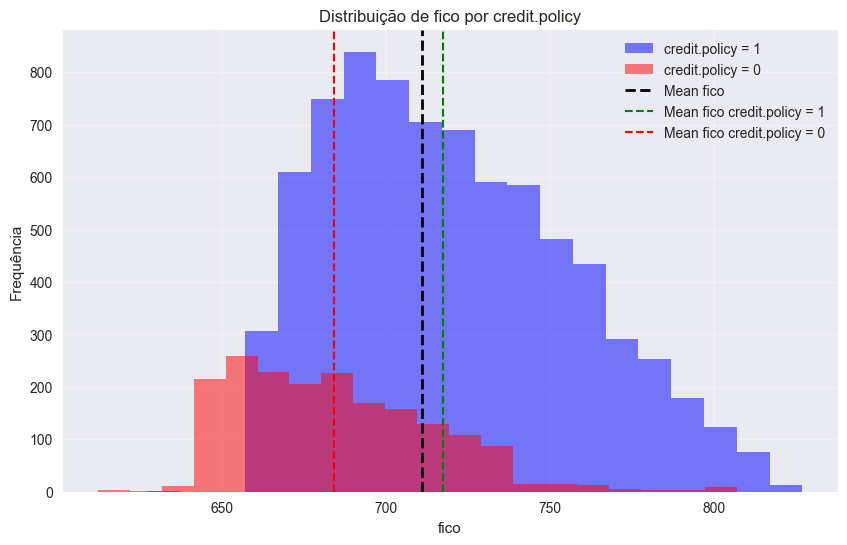

In [142]:
# Distribuição FICO por política de crédito
plot_histogram_with_means(df, 'fico', 'credit.policy')

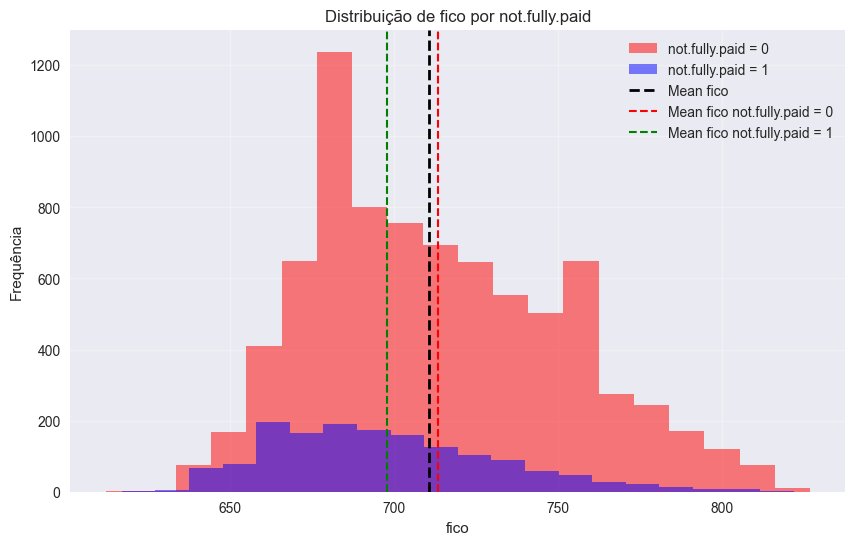

In [143]:
# Distribuição FICO por status de pagamento
plot_histogram_with_means(df, 'fico', 'not.fully.paid')

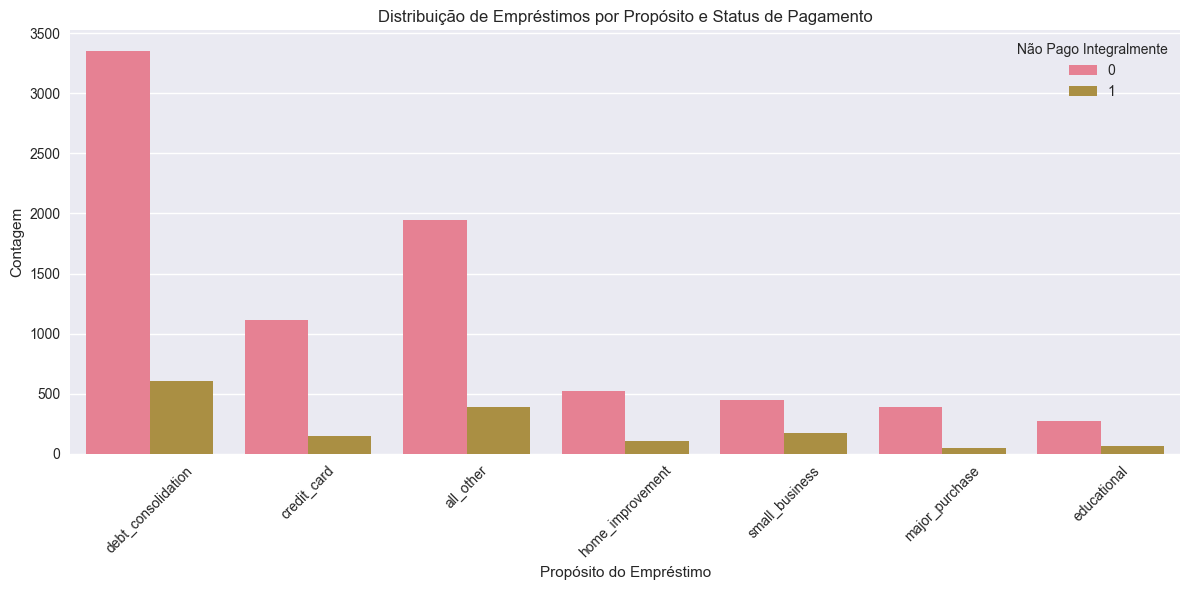

In [144]:
# Contagem de empréstimos por propósito e status de pagamento
plt.figure(figsize=(12, 6))
sns.countplot(x='purpose', hue='not.fully.paid', data=df)
plt.title('Distribuição de Empréstimos por Propósito e Status de Pagamento')
plt.xlabel('Propósito do Empréstimo')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.legend(title='Não Pago Integralmente')
plt.tight_layout()

Text(0.5, 1.02, 'Relação entre FICO e Taxa de Juros')

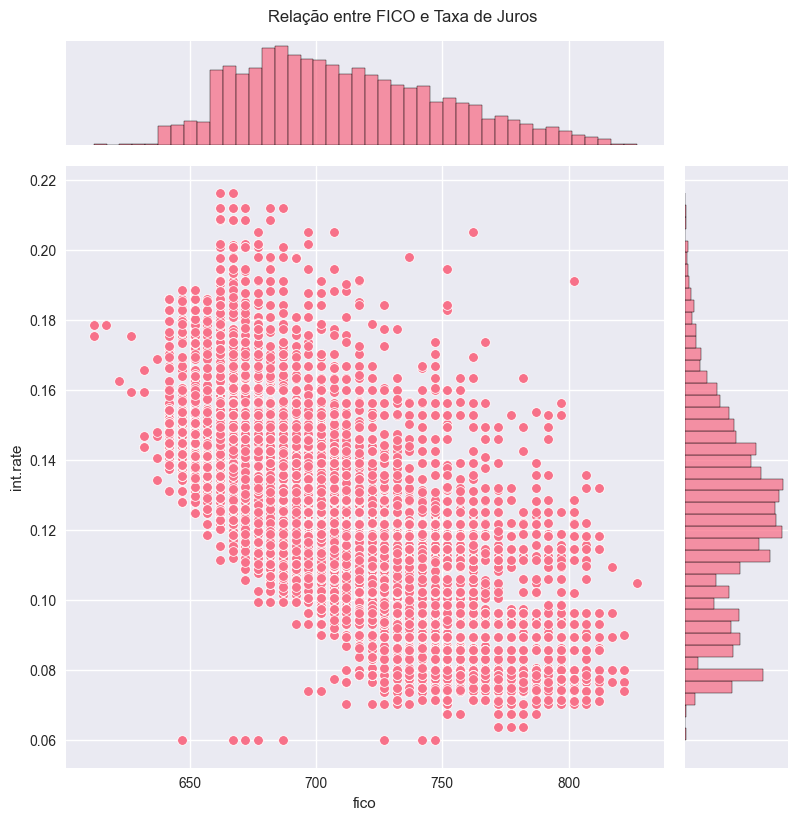

In [145]:
# Relação entre score FICO e taxa de juros
sns.jointplot(x='fico', y='int.rate', data=df, height=8)
plt.suptitle('Relação entre FICO e Taxa de Juros', y=1.02)

Text(0.5, 1.02, 'Regressão Linear: FICO vs Taxa de Juros')

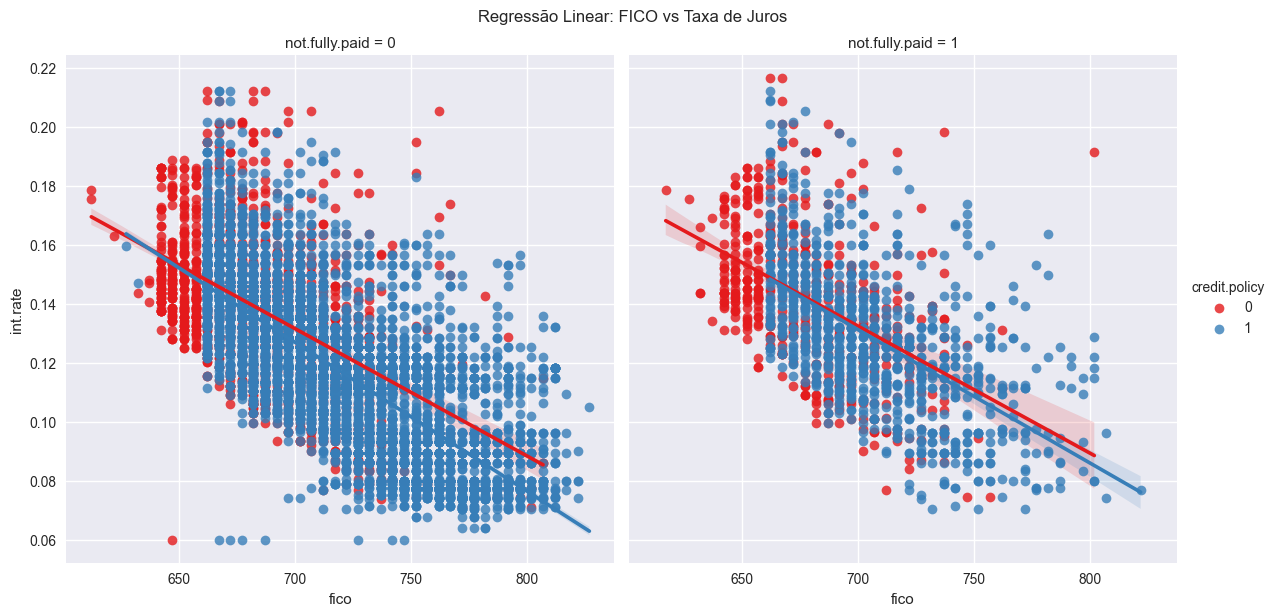

In [146]:
# Relação entre FICO e taxa de juros por política de crédito e status de pagamento
sns.lmplot(x='fico', y='int.rate', data=df, hue='credit.policy', 
           col='not.fully.paid', palette='Set1', height=6)
plt.suptitle('Regressão Linear: FICO vs Taxa de Juros', y=1.02)

In [147]:
# Definição das features categóricas para codificação
cat_features = ['purpose']

In [148]:
# Criação de cópia do dataset e aplicação de one-hot encoding
loans = df.copy()
loans = pd.get_dummies(loans, columns=cat_features, drop_first=True, dtype=int)
loans.head()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,0,1,0,0,0,0
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,1,0,0,0,0,0
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,0,1,0,0,0,0
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,0,1,0,0,0,0
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,1,0,0,0,0,0


In [149]:
# Verificação das informações após codificação
loans.info()

<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   credit.policy               9578 non-null   int64  
 1   int.rate                    9578 non-null   float64
 2   installment                 9578 non-null   float64
 3   log.annual.inc              9578 non-null   float64
 4   dti                         9578 non-null   float64
 5   fico                        9578 non-null   int64  
 6   days.with.cr.line           9578 non-null   float64
 7   revol.bal                   9578 non-null   int64  
 8   revol.util                  9578 non-null   float64
 9   inq.last.6mths              9578 non-null   int64  
 10  delinq.2yrs                 9578 non-null   int64  
 11  pub.rec                     9578 non-null   int64  
 12  not.fully.paid              9578 non-null   int64  
 13  purpose_credit_card         9578 non-null   

In [150]:
# Imports já realizados no topo do notebook

In [151]:
# Separação das features (X) e target (y)
X = loans.drop('not.fully.paid', axis=1)
y = loans['not.fully.paid']

In [152]:
# Divisão dos dados em treino e teste (70% treino, 30% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [153]:
# Imports já realizados no topo do notebook

In [154]:
# Criação e treinamento do modelo Decision Tree
dtree = DecisionTreeClassifier(random_state=101)
dtree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",101
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

In [155]:
# Predições com o modelo Decision Tree
predictions = dtree.predict(X_test)

In [156]:
# Imports já realizados no topo do notebook

In [157]:
# Relatório de classificação do Decision Tree
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.85      0.81      0.83      2431
           1       0.19      0.24      0.21       443

    accuracy                           0.72      2874
   macro avg       0.52      0.53      0.52      2874
weighted avg       0.75      0.72      0.74      2874



In [158]:
# Matriz de confusão do Decision Tree
print(confusion_matrix(y_test, predictions))

[[1975  456]
 [ 336  107]]


In [159]:
# Imports já realizados no topo do notebook

In [160]:
# Criação e treinamento do modelo Random Forest
rfc = RandomForestClassifier(n_estimators=600, random_state=101)
rfc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",600
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [161]:
# Predições com o modelo Random Forest
rfc_pred = rfc.predict(X_test)

In [162]:
# Relatório de classificação do Random Forest
print(classification_report(y_test, rfc_pred))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2431
           1       0.52      0.03      0.05       443

    accuracy                           0.85      2874
   macro avg       0.69      0.51      0.48      2874
weighted avg       0.80      0.85      0.78      2874



In [163]:
# Matriz de confusão do Random Forest
print(confusion_matrix(y_test, rfc_pred))

[[2420   11]
 [ 431   12]]


---

## 📝 Conclusão

### Principais Descobertas

1. **Desbalanceamento de Classes**: O dataset apresenta ~84% de mutuários que pagaram integralmente vs ~16% que não pagaram, o que impacta significativamente a performance dos modelos.

2. **Performance dos Modelos**:
   - **Decision Tree**: Acurácia de 72%, com recall de 24% para a classe minoritária. Identifica melhor os inadimplentes, mas com muitas falsos positivos.
   - **Random Forest**: Acurácia de 85%, mas recall de apenas 3% para a classe minoritária. O modelo praticamente ignora a classe 1, focando em acurácia global.

3. **Análise Exploratória**:
   - Mutuários com política de crédito aprovada tendem a ter scores FICO mais altos
   - Não há diferença significativa no score FICO entre pagadores e não pagadores
   - Taxas de juros mais altas estão associadas a scores FICO mais baixos
   - A maioria dos empréstimos é para consolidação de dívidas

### Limitações

- **Desbalanceamento**: A classe minoritária é sub-representada, dificultando a aprendizagem
- **Features Limitadas**: O dataset não inclui informações adicionais que poderiam ser preditivas (histórico de emprego, ativos, etc.)
- **Período dos Dados**: Dados de 2007-2010 podem não refletir o comportamento atual do mercado

### Próximos Passos Prioritários

1. **Balancear as classes** usando SMOTE ou class weights
2. **Feature engineering** para criar variáveis derivadas mais informativas
3. **Ajuste de hiperparâmetros** com foco em recall da classe 1
4. **Experimentar algoritmos de gradient boosting** (XGBoost, LightGBM)
5. **Usar métricas mais adequadas** como ROC-AUC e Precision-Recall AUC

### Referências

- LendingClub: https://www.lendingclub.com/
- Dataset: Empréstimos de 2007-2010 (dados públicos pré-2016)

---

**Nota**: Este notebook é parte do projeto "Simple Credit Analysis". Para mais informações, consulte o `README.md`.

# Próximos Passos para Melhorar a Performance dos Modelos

Os resultados obtidos com os modelos **Decision Tree** e **Random Forest** indicam dificuldade em identificar corretamente os mutuários que não pagarão o empréstimo (classe `not.fully.paid = 1`), especialmente devido ao desbalanceamento das classes (~84% classe 0 vs ~16% classe 1). Abaixo estão as principais diretrizes para aprimorar os modelos:

---

## 1. Tratamento do Desbalanceamento de Classes
- **SMOTE (Synthetic Minority Over-sampling Technique)**: gerar amostras sintéticas da classe minoritária para equilibrar o dataset.
- **Undersampling da classe majoritária**: reduzir a quantidade de exemplos da classe 0 para balancear o treinamento.
- **Class weights**: ajustar o parâmetro `class_weight='balanced'` nos classificadores para penalizar mais erros na classe minoritária.

## 2. Feature Engineering
- **Criar novas variáveis**: por exemplo, razão `installment / log.annual.inc` (parcela em relação à renda), `revol.bal / revol.util` (endividamento relativo), categorização do score FICO em faixas.
- **Transformações logarítmicas**: aplicar em variáveis com distribuição assimétrica, como `revol.bal` e `days.with.cr.line`.
- **Interações entre features**: testar produtos ou somas entre variáveis financeiras correlacionadas (ex: `dti * int.rate`).
- **Binning**: transformar variáveis contínuas em categorias ordinais quando houver relação não-linear com o target.

## 3. Normalização e Padronização dos Dados
- **StandardScaler**: padronizar features contínuas para média 0 e desvio padrão 1 — essencial se forem testados modelos sensíveis à escala (Logistic Regression, SVM, Neural Networks, KNN).
- **MinMaxScaler**: normalizar para intervalo [0, 1] caso necessário.
- Apesar de árvores serem invariantes à escala, normalizar permite comparar modelos distintos de forma justa.

## 4. Seleção e Redução de Features
- **Análise de correlação**: remover features altamente correlacionadas que não agregam informação nova.
- **Feature importance**: utilizar a importância das features do Random Forest para eliminar variáveis irrelevantes.
- **PCA (Principal Component Analysis)**: reduzir dimensionalidade caso haja multicolinearidade entre variáveis financeiras.

## 5. Ajuste de Hiperparâmetros (Hyperparameter Tuning)
- **GridSearchCV / RandomizedSearchCV**: otimizar parâmetros como `max_depth`, `min_samples_split`, `min_samples_leaf`, `n_estimators` e `max_features`.
- **Validação cruzada estratificada (StratifiedKFold)**: garantir que cada fold mantenha a proporção das classes, essencial para datasets desbalanceados.

## 6. Experimentar Outros Algoritmos
- **XGBoost / LightGBM / CatBoost**: gradient boosting frequentemente supera Random Forest em problemas tabulares.
- **Logistic Regression**: como baseline interpretável, especialmente útil com dados normalizados.
- **SVM e Neural Networks**: testar em pipelines com dados padronizados.

## 7. Métricas de Avaliação Mais Adequadas
- **Focar em recall da classe 1**: para um investidor, perder um empréstimo inadimplente é mais custoso que rejeitar um pagador.
- **ROC-AUC e Precision-Recall AUC**: mais informativas que acurácia em dados desbalanceados.
- **Threshold tuning**: ajustar o ponto de corte de probabilidade ao invés de usar o default 0.5.

## 8. Análise de Erros (Error Analysis)
- Inspecionar os casos de **falsos negativos** (mutuários classificados como pagadores, mas que não pagam) para identificar padrões comuns.
- Analisar os **falsos positivos** para entender se há perfis específicos sendo injustamente classificados como inadimplentes.

---

> **Conclusão**: a acurácia de 85% do Random Forest é enganosa — o modelo praticamente ignora a classe minoritária. Os próximos passos mais prioritários são: **(1) balancear as classes**, **(2) criar features derivadas** e **(3) tunar hiperparâmetros com métricas focadas em recall da classe 1**.